In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

In [2]:
B, n =10000, 30
mu, sigma = 100, 10
alpha=0.05
z_alpha2=ss.norm.ppf(1-alpha/2)
Xbar, Sig2, LCL, UCL=[], [], [], []

In [19]:
for _ in range(B):
    s0=np.random.normal(mu,sigma,n)
    Xbar.append(np.mean(s0))
    Sig2.append(np.var(s0,ddof=1))

LCL=Xbar-z_alpha2*np.sqrt(Sig2)/np.sqrt(n-1)
UCL=Xbar+z_alpha2*np.sqrt(Sig2)/np.sqrt(n-1)
df=pd.DataFrame({"Xbar":Xbar,"Sig2":Sig2,"Lower":LCL,"Upper":UCL,"MeanInCI":(LCL<mu)&(mu<UCL)})
np.mean(df.MeanInCI)

0.9445333333333333

<Axes: ylabel='Density'>

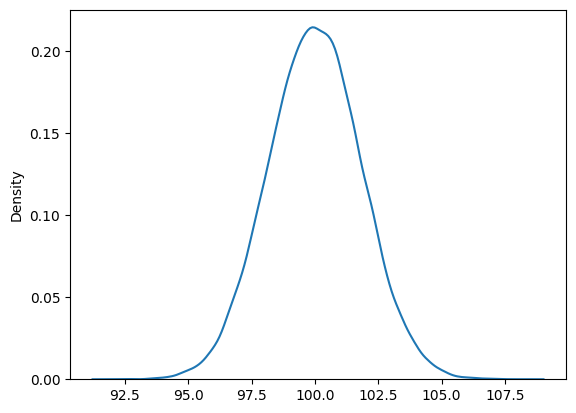

In [20]:
sns.kdeplot(Xbar)

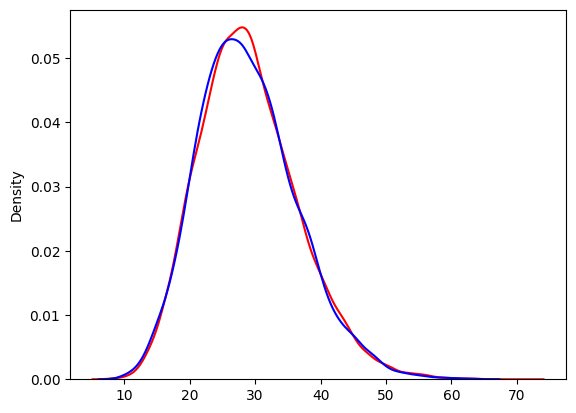

In [21]:

sns.kdeplot((n-1)*np.array(Sig2)/(sigma**2),color="Red")
sns.kdeplot(np.random.chisquare(n-1,10000),color="Blue")
plt.show()

$$\hat{P}=\frac{x}{n}$$
$$Var(\hat{P})=\frac{\hat{P}\times(1-\hat{P})}{n}$$